### Integrantes:
- Valentina Giraldo Gaviria
- Sara Emanuelle Calderón

## **1. Carga de paquetes**

In [1]:
#%pip install pmdarima

In [2]:
from pmdarima.arima import auto_arima, ARIMA
from statsmodels.tsa.stattools import acf, pacf
import pandas as pd
import numpy as np
import statsmodels.api as sm
from matplotlib import pyplot as plt
from sklearn.metrics import root_mean_squared_error, mean_squared_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import seaborn as sns
from scipy import stats
from statsmodels.sandbox.stats.runs import runstest_1samp # prueba de rachas de Wald y Wolfowitz
from statsmodels.tsa.exponential_smoothing.ets import ETSModel

### **2. Carga de los datos**

In [ ]:
data = pd.read_excel(r"Series de tiempo/datosEmpleo.xlsx",index_col='mes',parse_dates=True)
data.head()

,TD_13ciudades,Ocupados,Desocupados,Inactivos
mes,,,,
2001-01-01,20.946380,6923.604,1834.507,4600.718
2001-02-01,19.894213,7037.746,1747.820,4596.805
2001-03-01,19.221565,6945.973,1652.823,4807.120
2001-04-01,17.888575,6973.079,1519.137,4937.280
2001-05-01,17.945654,6994.462,1529.720,4928.911


## **2. ACF y PACF**

El objetivo es poder analizar el comportamiento de las Funciones de Autocorrelación para previamente tener un indicio de los parámetros del modelo a utilizar. 

In [4]:
#Función de Autocorrelación

acf(data['Ocupados'], nlags=40)

array([1.        , 0.97855484, 0.96290943, 0.94999592, 0.93767278,
       0.92828634, 0.91803512, 0.90827078, 0.89628125, 0.88592368,
       0.8772359 , 0.8728291 , 0.86780346, 0.84936325, 0.83206921,
       0.81773834, 0.80588679, 0.79695724, 0.78708534, 0.77639894,
       0.76345987, 0.75177965, 0.74296472, 0.73663393, 0.73128083,
       0.71333785, 0.69520217, 0.68008434, 0.66685076, 0.65659735,
       0.64390143, 0.63170587, 0.6184013 , 0.60541159, 0.59596135,
       0.58936238, 0.5824738 , 0.56326155, 0.54546119, 0.53051481,
       0.51728811])

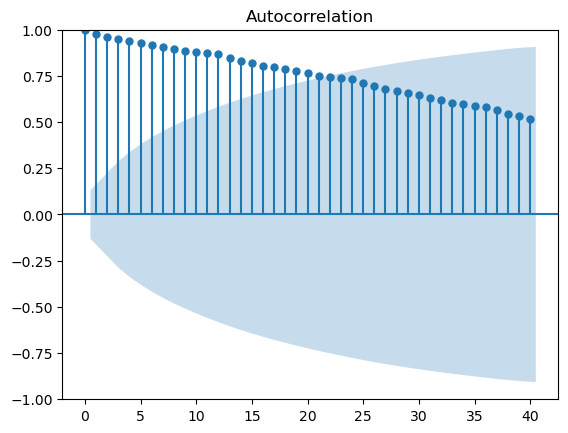

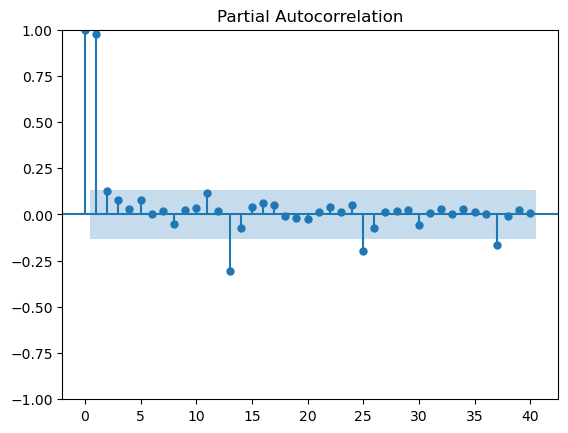

In [5]:
#Gráficas de ACF y PACF

plot_acf(data['Ocupados'],lags=40);
plot_pacf(data['Ocupados'],lags=40);

Teniendo en cuenta los gráficos anteriores, se observa que en la **ACF** el comportamiento de la autocorrelación disminuye de forma gradual pero no es un comportamiento muy acelerado, es decir que, es posible que no nos estemos enfrentando a una serie estacionaria. Por tanto, es necesario diferenciar. 

## **3. Protocolo de Evaluación (Hold-Out)**

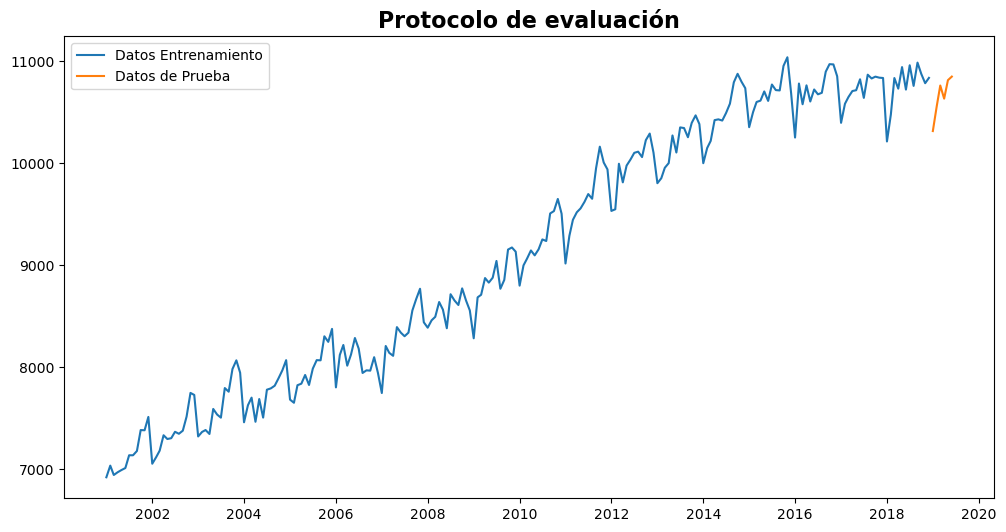

In [6]:
# Separamos un conjunto de entrenamiento y otro de prueba para evaluar pronóstico out-of-sample (6 meses).
train_len = 216
train_td = data[["Ocupados"]][:train_len]
test_td = data[["Ocupados"]][train_len:]

plt.figure(figsize=(12,6))
plt.title("Protocolo de evaluación",fontsize=16, fontweight='bold')
plt.plot(train_td,label="Datos Entrenamiento")
plt.plot(test_td,label="Datos de Prueba")
plt.legend()
plt.show()

## **4. AUTOARIMA**

In [7]:
model = auto_arima(train_td["Ocupados"], 
                   max_p=10, 
                   max_q=10, 
                   information_criterion='aic', 
                   trace=True, 
                   error_action='ignore',  
                   suppress_warnings=True,
                   stepwise=True,
                   seasonal=False) 
model.summary()

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.30 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=2864.791, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=2855.272, Time=0.03 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=2846.080, Time=0.07 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=2864.805, Time=0.02 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=2825.418, Time=0.14 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=2826.765, Time=0.18 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=2826.900, Time=0.25 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=2828.288, Time=0.12 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=2849.394, Time=0.03 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=2842.993, Time=0.05 sec

Best model:  ARIMA(1,1,1)(0,0,0)[0] intercept
Total fit time: 1.216 seconds


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  216
Model:               SARIMAX(1, 1, 1)   Log Likelihood               -1408.709
Date:                Sat, 15 Nov 2025   AIC                           2825.418
Time:                        09:35:56   BIC                           2838.901
Sample:                    01-01-2001   HQIC                          2830.866
                         - 12-01-2018                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     10.2480      2.382      4.303      0.000       5.580      14.916
ar.L1          0.4446      0.096      4.642      0.000       0.257       0.632
ma.L1         -0.8707      0.049    -17.901      0.000      -0.966      -0.775
sigma2      2.853e+04   2438.811     11.699      0.000    2.38e+04    3.33e+04
===================================================================================
Ljung-Box (L1) (Q):                   0.08   Jarque-Bera (JB):                47.82
Prob(Q):                              0.78   Prob(JB):                         0.00
Heteroskedasticity (H):               1.21   Skew:                            -0.92
Prob(H) (two-sided):                  0.42   Kurtosis:                         4.39
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

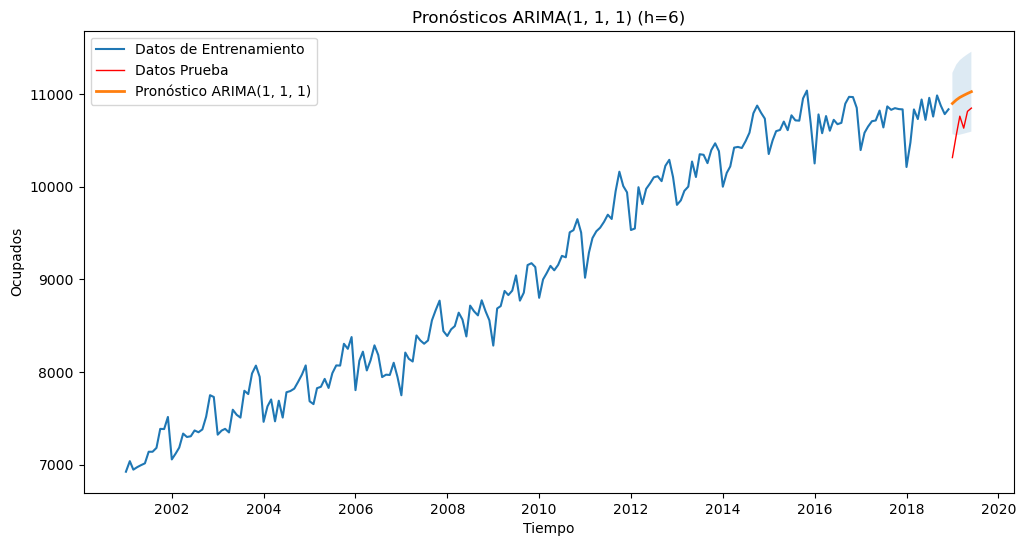

In [8]:
# Horizonte de predicción
h = 6 

# Realizar las predicciones
y_forec, conf_int = model.predict(n_periods=h, return_conf_int=True, alpha=0.05)

pred_index = test_td.index[:h]

# Preparar DataFrame para predicciones y intervalos de confianza
preds = pd.DataFrame({
    'Point_forecast': y_forec,
    'lower_95': conf_int[:, 0],
    'upper_95': conf_int[:, 1],
}, index=pred_index)
preds.columns = ['Point_forecast', 'lower_95', 'upper_95']

# Graficar
plt.figure(figsize=(12, 6))
plt.plot(train_td['Ocupados'].index, train_td['Ocupados'], label="Datos de Entrenamiento")
plt.plot(test_td, label="Datos Prueba", color='red', linewidth=1)
plt.plot(pred_index,    y_forec, label=f"Pronóstico ARIMA{model.order}", lw=2)
plt.fill_between(pred_index, conf_int[:, 0], conf_int[:, 1], alpha=0.15)
plt.legend()
plt.xlabel("Tiempo")
plt.ylabel("Ocupados")
plt.title(f"Pronósticos ARIMA{model.order} (h={h})")
plt.show()

In [9]:
#Alinea verdaderos con el horizonte pronosticado
y_true = test_td.iloc[:h].to_numpy().ravel() 

# RMSE
rmse = np.sqrt(mean_squared_error(y_true, y_forec))
print("RMSE:", rmse)

RMSE: 346.2354041462504


## **5. Evaluación del Modelo - Datos Completos**

In [10]:
full_model = ARIMA(order=(1,1,1))
results = full_model.fit(data["Ocupados"])
results.summary()

c:\Users\1116282909\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\1116282909\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  222
Model:               SARIMAX(1, 1, 1)   Log Likelihood               -1451.595
Date:                Sat, 15 Nov 2025   AIC                           2911.190
Time:                        09:35:57   BIC                           2924.782
Sample:                    01-01-2001   HQIC                          2916.678
                         - 06-01-2019                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      9.8551      2.485      3.965      0.000       4.984      14.726
ar.L1          0.4419      0.101      4.357      0.000       0.243       0.641
ma.L1         -0.8618      0.053    -16.414      0.000      -0.965      -0.759
sigma2      2.948e+04   2480.399     11.885      0.000    2.46e+04    3.43e+04
===================================================================================
Ljung-Box (L1) (Q):                   0.05   Jarque-Bera (JB):                57.86
Prob(Q):                              0.83   Prob(JB):                         0.00
Heteroskedasticity (H):               1.29   Skew:                            -0.99
Prob(H) (two-sided):                  0.28   Kurtosis:                         4.53
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

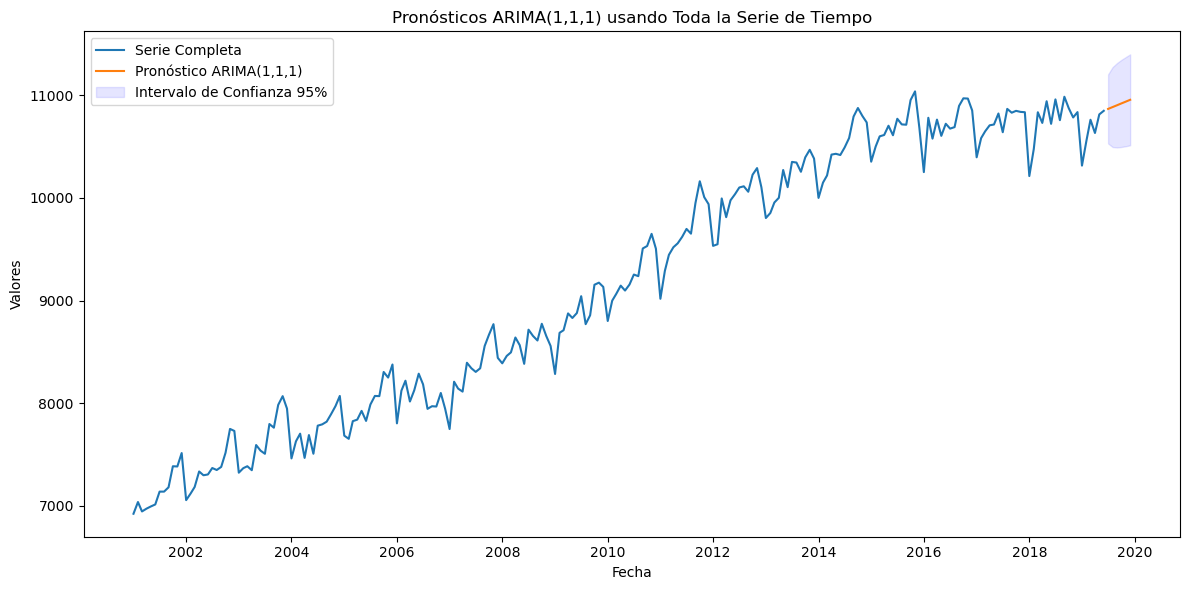

In [11]:
# Horizonte de predicción
h = 6  

# Realizar las predicciones usando el modelo ajustado en toda la serie
y_forec, conf_int = results.predict(n_periods=h,return_conf_int=True, alpha=0.05)

# Construir índice futuro con la frecuencia real (o inferida)
y_full = data["Ocupados"]
freq = y_full.index.freq or pd.infer_freq(y_full.index)
if freq is not None:
    future_index = pd.date_range(start=y_full.index[-1] + pd.tseries.frequencies.to_offset(freq),
                                 periods=h, freq=freq)
else:
    # fallback razonable (mensual inicio de mes); ajusta si tu serie no es mensual
    future_index = pd.date_range(start=y_full.index[-1], periods=h+1, freq='MS')[1:]

# Preparar DataFrame para predicciones y intervalos de confianza
preds = pd.DataFrame({
    "Point_forecast": y_forec,
    "lower_95": conf_int[:, 0],
    "upper_95": conf_int[:, 1],
})
preds.columns = ['Point_forecast', 'lower_95', 'upper_95']


# Graficar
fig = plt.figure(figsize=(12, 6))
plt.plot(y_full.index, y_full.values, label="Serie Completa")
plt.plot(future_index, y_forec, label="Pronóstico ARIMA(1,1,1)")
plt.fill_between(future_index, conf_int[:, 0], conf_int[:, 1], color='blue', alpha=0.1, label='Intervalo de Confianza 95%')
plt.legend()
plt.xlabel("Fecha")
plt.ylabel("Valores")
plt.title("Pronósticos ARIMA(1,1,1) usando Toda la Serie de Tiempo")
plt.tight_layout()
plt.show()

In [12]:
# Crear una tabla para mostrar predicciones y valores reales
# Generar las fechas para el horizonte de predicción
forecast_dates = pd.date_range(start=data["Ocupados"].index[-1] + pd.DateOffset(1), periods=h)  # Ajusta 'freq' según la frecuencia de los datos

# Crear la tabla de predicciones
forecast_table = pd.DataFrame({
    'Fecha': forecast_dates,
    'Predicciones': y_forec
})

print(forecast_table)

                Fecha  Predicciones
2019-07-01 2019-06-02  10866.345101
2019-08-01 2019-06-03  10884.306919
2019-09-01 2019-06-04  10902.099364
2019-10-01 2019-06-05  10919.816962
2019-11-01 2019-06-06  10937.501485
2019-12-01 2019-06-07  10955.171393


## **6. Comprobación de supuestos del mejor modelo**

Debido al proceso de diferenciación realizado en la serie temporal, donde se realiza una resta entre las observaciones consecutivas, el primer valor del residuo de la serie diferenciada no será tomado en cuenta. Esto es porque el primer residuo se basa en la diferencia entre el primer y el segundo dato, y puede no ser representativo del patrón general de la serie. Este primer residuo puede estar influenciado por la falta de un dato previo, lo que lo hace menos confiable para evaluar el comportamiento general del modelo.

In [13]:
y_hat_in = pd.Series(results.predict_in_sample(), index=data["Ocupados"].index)
residuals = (data["Ocupados"] - y_hat_in).dropna().iloc[1:]

residuals_df = residuals.reset_index()
residuals_df.columns = ['Mes', 'Residuo']

print(residuals.tail())

mes
2019-02-01    -33.944118
2019-03-01     56.155412
2019-04-01   -179.849549
2019-05-01     73.008209
2019-06-01      8.094889
dtype: float64


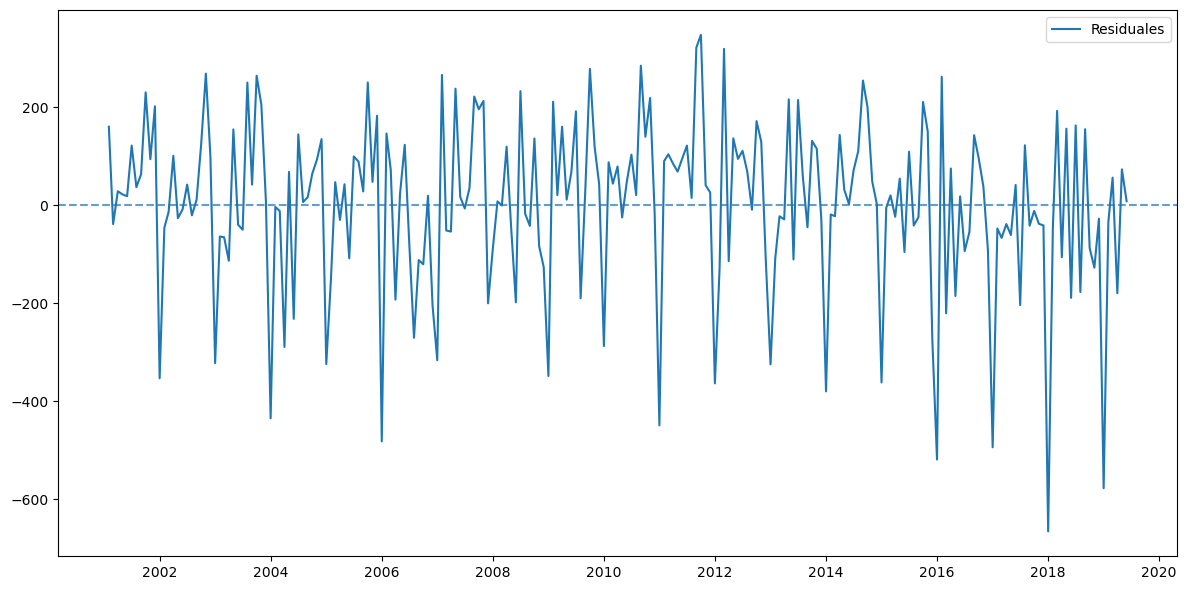

In [14]:
fig = plt.figure(figsize=(12, 6))
plt.plot(residuals.index, residuals.values, label="Residuales")
plt.axhline(0, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

### I) Normalidad de los residuos

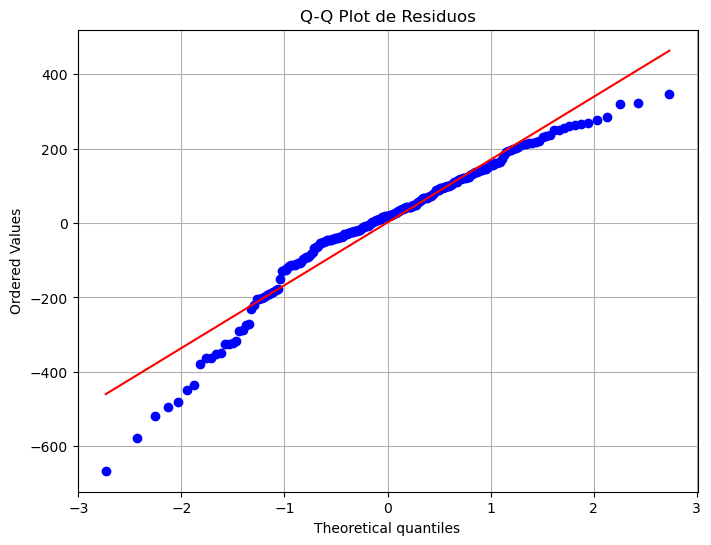

In [15]:
plt.figure(figsize=(8, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot de Residuos')
plt.grid(True)
plt.show()

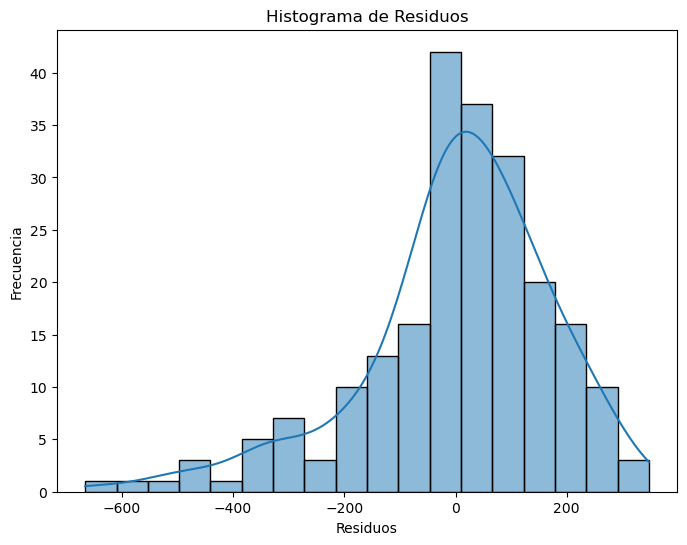

In [16]:
plt.figure(figsize=(8, 6))
sns.histplot(residuals, kde=True)
plt.xlabel('Residuos')
plt.ylabel('Frecuencia')
plt.title('Histograma de Residuos')
plt.show()

En el gráfico anterior se puede apreciar que la distribución presenta asimetría, lo anterior podría anticipar la NO existencia de normalidad en la distribución de los errores. Sin embargo, para confirmar esta sospecha, se procede a correr las pruebas de Jarque Bera y de Shapiro. En este caso, las pruebas de hipótesis de estas pruebas son las siguientes:

- H0: Los errores siguen una distribución normal
- H1: Los errores no siguen una distribución normal

In [17]:
shapiro_result = stats.shapiro(residuals_df.Residuo)
print(f"Resultados prueba Shapiro: {shapiro_result}")

Jarque_bera_result=stats.jarque_bera(residuals_df.Residuo)
print(f"Resultados prueba Jarque-Bera: {Jarque_bera_result}")

Resultados prueba Shapiro: ShapiroResult(statistic=0.9428420211546774, pvalue=1.250533994572043e-07)
Resultados prueba Jarque-Bera: SignificanceResult(statistic=57.634452484306145, pvalue=3.0537793869264357e-13)


Al revisar la tabla anterior con los resultados del modelo, se puede evidenciar que los p-valores asociado a ambos test son menores al nivel de significancia de 0.05, por lo que **se rechaza** la hipótesis nula de normalidad. En este sentido, se evidencia que **los errores NO siguen una distribución normal**.

### II) Homocedasticidad de los residuos

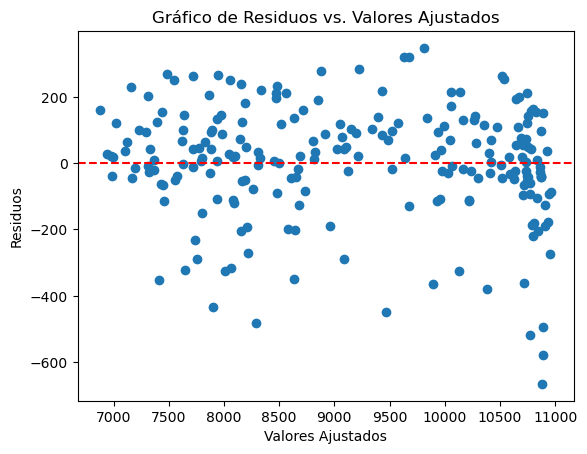

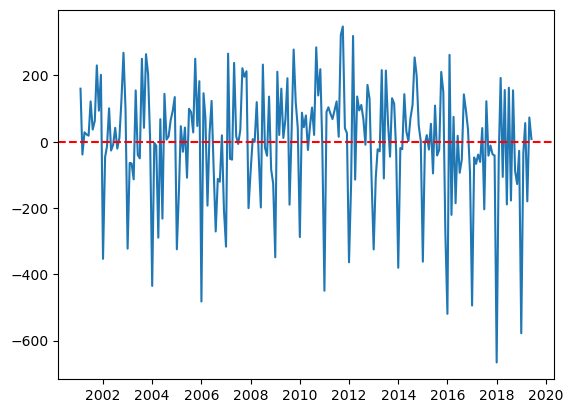

In [18]:
predicted = y_hat_in.loc[residuals.index]

plt.scatter(predicted, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Valores Ajustados')
plt.ylabel('Residuos')
plt.title('Gráfico de Residuos vs. Valores Ajustados')
plt.show()


plt.plot(residuals,label="Residuales del Modelo")
plt.axhline(y=0, color='red', linestyle='--')
plt.show()

#### **prueba de Ljung-Box**

- H0: Comportamiento Homoscedastico (Es decir varianza constante) 
- H1: Comportamiento Heteroscedastico (Es decir varianza no constante)

In [19]:
sm.stats.acorr_ljungbox((residuals_df.Residuo-residuals_df.Residuo.mean())**2, lags=range(1,21), return_df=True,boxpierce=True )

,lb_stat,lb_pvalue,bp_stat,bp_pvalue
1,0.790396,3.739803e-01,0.779763,3.772135e-01
2,1.414413,4.930196e-01,1.392587,4.984294e-01
3,1.415592,7.018840e-01,1.393739,7.070029e-01
4,3.026000,5.534838e-01,2.960818,5.644037e-01
5,4.680196,4.561415e-01,4.563089,4.714870e-01
6,4.808126,5.686476e-01,4.686429,5.846125e-01
7,6.290977,5.062138e-01,6.109435,5.270310e-01
8,6.869131,5.508162e-01,6.661662,5.735371e-01
9,7.245318,6.115949e-01,7.019293,6.351106e-01
10,8.586257,5.717666e-01,8.288073,6.007209e-01


Todos los p-valores asociados a la prueba de Ljung-Box son mayores a un nivel de significancia de 0.05. Por lo tanto, la evidencia NO permite rechazar la hipótesis nula de comportamiento homoscedástico (no auto-correlación de las varianzas), y por tanto **NO hay evidencia de comportamiento ARCH o GARCH** en los residuos del modelo.

### III) Autocorrelación de los residuos

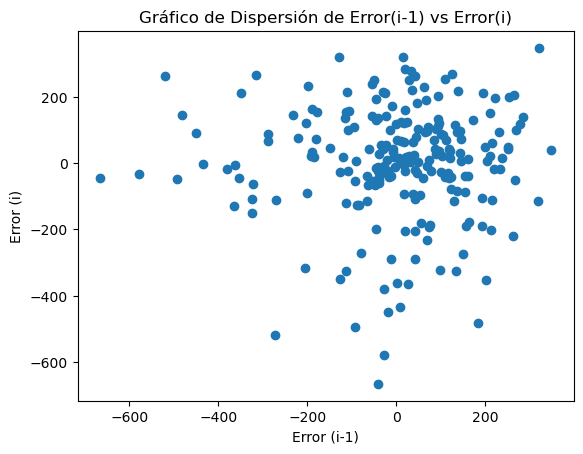

In [20]:
residuals_i_1 = residuals[:-1]
residuals_i = residuals[1:]

plt.scatter(residuals_i_1, residuals_i)
plt.title('Gráfico de Dispersión de Error(i-1) vs Error(i)')
plt.xlabel('Error (i-1)')
plt.ylabel('Error (i)')
plt.show()

Para determinar si existe autocorrelación vamos a usar la prueba de rachas propuesta por Wald y Wolfowitz, 1940. Es una prueba no paramétrica donde las hipótesis son las siguientes:

$H{0}: ρ = 0$ (Es decir no hay autocorrelación) 

$H{1}: ρ \not= 0$ (Es decir hay autocorrelación)

Rechazo $H{0}$ cuando el p-valor es menor al nivel de significancia, convencionalmente se usa un $α$=0.05 ($α$ = nivel de significancia).

In [21]:
signo = residuals_df.Residuo>0
runstest_1samp(signo, correction=False)

(-1.4853925230454101, 0.13743987515420775)

El segundo valor corresponde al p-valor=0.13743987515420775, por lo tanto considerando un $α$=0.05, los resultados obtenidos NO permiten rechazar la hipótesis nula, es decir, los residuos no tienen evidencia suficiente de correlación-

Este resultado se complementará con otras pruebas como la prueba de Box-Pierce y la modificación de Ljung-Box para muestras pequeñas.

In [22]:
# prueba de Box-Pierce y la modificación de Ljung-Box 
sm.stats.acorr_ljungbox(residuals_df.Residuo, lags=[1], return_df=True,boxpierce=True)

,lb_stat,lb_pvalue,bp_stat,bp_pvalue
1,0.045439,0.8312,0.044827,0.832322


Con el resultado anterior no rechazamos la hipótesis nula de no autocorrelación para el primer rezago, lo ideal antes de tomar la decisión es probar por lo menos los primeros 20 rezagos.

In [23]:
Resul_lb_bp = sm.stats.acorr_ljungbox(residuals_df.Residuo, lags=range(1,21), return_df=True,boxpierce=True )
Resul_lb_bp["lb_ho"] = np.where(Resul_lb_bp['lb_pvalue']<0.05, 'rechazo_ho/hay_autocorr', 'no_rechazo_ho/no_hay_autocorr')
Resul_lb_bp["bp_ho"] = np.where(Resul_lb_bp['bp_pvalue']<0.05, 'rechazo_ho/hay_autocorr', 'no_rechazo_ho/no_hay_autocorr')
Resul_lb_bp

,lb_stat,lb_pvalue,bp_stat,bp_pvalue,lb_ho,bp_ho
1,0.045439,8.311998e-01,0.044827,8.323221e-01,no_rechazo_ho/no_hay_autocorr,no_rechazo_ho/no_hay_autocorr
2,0.106739,9.480296e-01,0.105028,9.488410e-01,no_rechazo_ho/no_hay_autocorr,no_rechazo_ho/no_hay_autocorr
3,0.247923,9.695055e-01,0.243046,9.703581e-01,no_rechazo_ho/no_hay_autocorr,no_rechazo_ho/no_hay_autocorr
4,1.572918,8.136512e-01,1.532391,8.208887e-01,no_rechazo_ho/no_hay_autocorr,no_rechazo_ho/no_hay_autocorr
5,2.239299,8.151396e-01,2.177855,8.240282e-01,no_rechazo_ho/no_hay_autocorr,no_rechazo_ho/no_hay_autocorr
6,4.254416,6.422899e-01,4.120681,6.603489e-01,no_rechazo_ho/no_hay_autocorr,no_rechazo_ho/no_hay_autocorr
7,5.058316,6.528466e-01,4.892137,6.731245e-01,no_rechazo_ho/no_hay_autocorr,no_rechazo_ho/no_hay_autocorr
8,6.900632,5.473908e-01,6.651837,5.746194e-01,no_rechazo_ho/no_hay_autocorr,no_rechazo_ho/no_hay_autocorr
9,7.556055,5.794275e-01,7.274930,6.085190e-01,no_rechazo_ho/no_hay_autocorr,no_rechazo_ho/no_hay_autocorr
10,9.247286,5.088072e-01,8.875153,5.439917e-01,no_rechazo_ho/no_hay_autocorr,no_rechazo_ho/no_hay_autocorr


El resultado es contundente, los residuos no parecen comportarse como un ruido blanco, esto confirma lo dictaminado por las anteriores pruebas y es que **No hay evidencia de presencia de autocorrelación**.

## **7. Boostrap**


El bootstrap es una técnica empleada en el análisis de series de tiempo cuando no hay cumplimiento del supuesto de normalidad, permite realizar mejores inferencias debido a que no requiere que los residuos sigan una distribución normal. En su defecto, se basa en el remuestreo de los datos observados. 

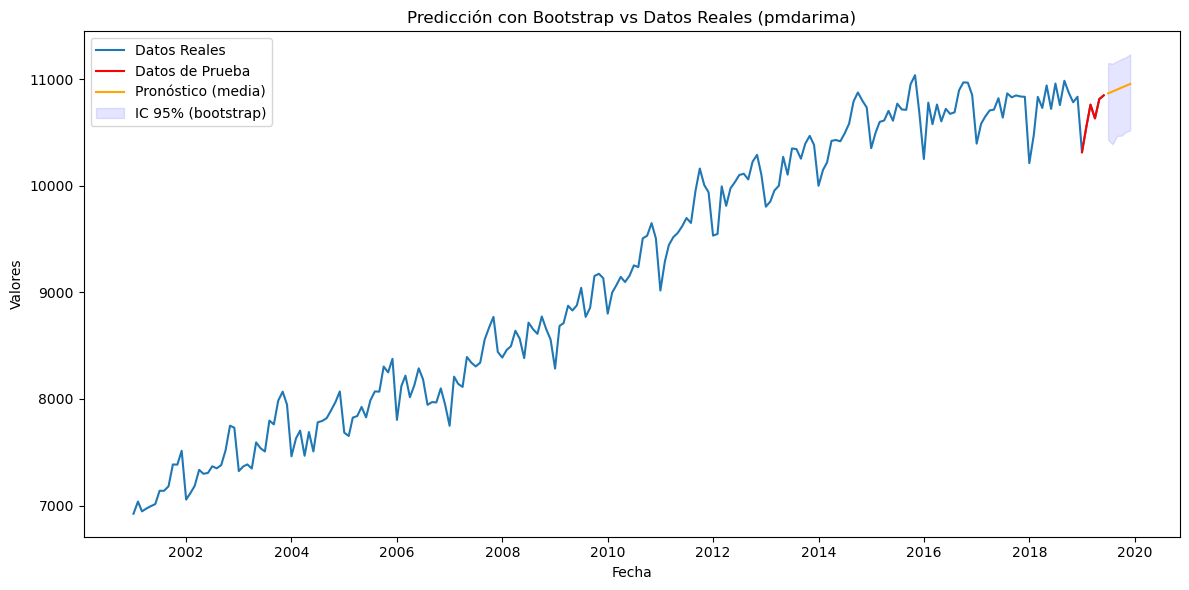

In [24]:
# Parámetros
h = 6
n_bootstrap = 1000
# np.random.seed(42) 

# Pronóstico futuro (pmdarima)
point_forecast, conf_int = results.predict(n_periods=h, return_conf_int=True, alpha=0.05)
point_forecast = np.asarray(point_forecast).ravel()  

# Residuos in-sample (pmdarima expone .arima_res_.resid)
if hasattr(results, "arima_res_") and hasattr(results.arima_res_, "resid"):
    residuals = np.asarray(results.arima_res_.resid)
else:
    # fallback según versión
    try:
        residuals = np.asarray(results.resid())
    except TypeError:
        residuals = np.asarray(results.resid)
residuals = residuals[~np.isnan(residuals)]

# Índice futuro usando la frecuencia real/inferida
freq = y_full.index.freq or pd.infer_freq(y_full.index)
if freq is not None:
    future_index = pd.date_range(start=y_full.index[-1] + pd.tseries.frequencies.to_offset(freq),
                                 periods=h, freq=freq)
else:
    # fallback mensual (ajusta si tu serie no es mensual)
    future_index = pd.date_range(start=y_full.index[-1], periods=h+1, freq="MS")[1:]

# --- Bootstrap: sumar residuos muestreados a la media pronosticada ---
sampled = np.random.choice(residuals, size=(n_bootstrap, h), replace=True)
bootstrap_forecasts = point_forecast + sampled  # broadcasting

lower_bound = np.percentile(bootstrap_forecasts, 2.5, axis=0)
upper_bound = np.percentile(bootstrap_forecasts, 97.5, axis=0)


pred_df = pd.DataFrame({
    "Point_forecast": np.asarray(point_forecast).ravel(),
    "lower_95": lower_bound,
    "upper_95": upper_bound
}, index=future_index)

# --- Gráfico ---
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(y_full.index, y_full.values, label="Datos Reales")
ax.plot(test_td.index, test_td.values, label="Datos de Prueba", color="red" )
ax.plot(future_index, point_forecast, label="Pronóstico (media)", color="orange")
ax.fill_between(future_index, lower_bound, upper_bound, color="blue", alpha=0.1, label="IC 95% (bootstrap)")
ax.set_title("Predicción con Bootstrap vs Datos Reales (pmdarima)")
ax.set_xlabel("Fecha"); ax.set_ylabel("Valores")
ax.legend()
plt.tight_layout(); plt.show()

In [25]:
preds

,Point_forecast,lower_95,upper_95
2019-07-01,10866.345101,10529.822706,11202.867496
2019-08-01,10884.306919,10495.268344,11273.345493
2019-09-01,10902.099364,10491.034848,11313.163879
2019-10-01,10919.816962,10495.515647,11344.118277
2019-11-01,10937.501485,10503.136257,11371.866714
2019-12-01,10955.171393,10512.066651,11398.276136


In [26]:
print(rmse)

346.2354041462504


## **8. Comparación modelo ARIMA vs modelo de suavización exponencial**

### 8.1 Modelo suavización exponencial Holt-Winters multiplicativo

In [27]:
train_len = 216
train_td = data[["Ocupados"]][:train_len]
test_td = data[["Ocupados"]][train_len:]

# Build model
ets_model = ETSModel(endog=train_td["Ocupados"],error="add", trend="mul", seasonal="mul", seasonal_periods=12, freq='MS')
ets_result = ets_model.fit()

point_forecast=ets_result.forecast(6)

ci = ets_result.get_prediction(start = point_forecast.index[0],
                                end = point_forecast.index[-1])

conf_forecast = ci.pred_int(alpha=0.05)
limits = ci.predicted_mean


preds_hw_add = pd.concat([limits, conf_forecast], axis = 1)
preds_hw_add.columns = ['Point_forecast', 'lower_95', 'upper_95']
print(preds_hw_add)

            Point_forecast      lower_95      upper_95
2019-01-01    10367.453253  10141.196337  10599.530614
2019-02-01    10585.349986  10341.868346  10841.491322
2019-03-01    10687.328027  10392.679056  10968.909853
2019-04-01    10715.035358  10418.995341  11025.709766
2019-05-01    10802.104452  10482.190980  11135.153381
2019-06-01    10775.737482  10440.742944  11132.101021


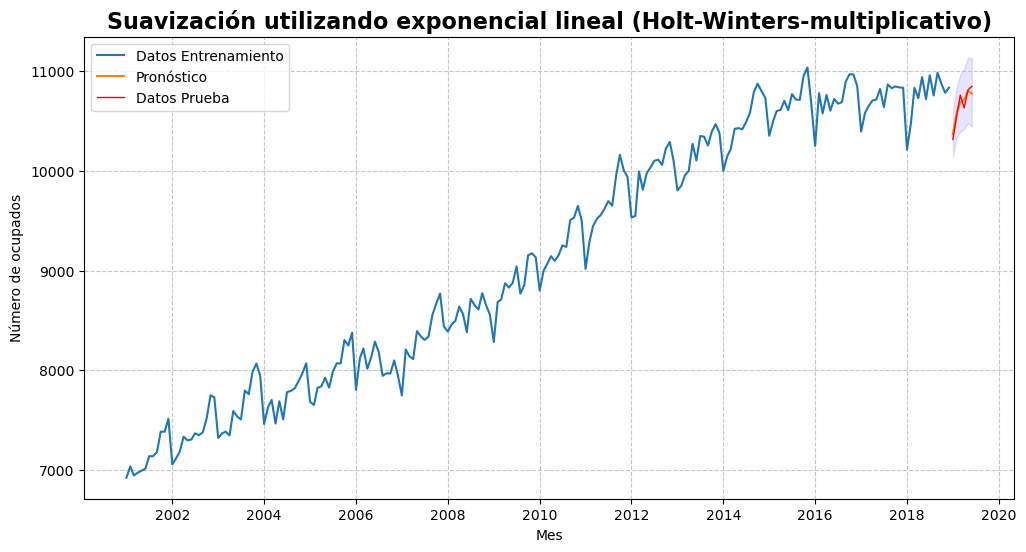

In [28]:
fig = plt.figure(figsize=(12, 6))
plt.title("Suavización utilizando exponencial lineal (Holt-Winters-multiplicativo)", fontsize=16, fontweight='bold')
plt.plot(train_td,label="Datos Entrenamiento")
plt.plot(preds_hw_add['Point_forecast'],label="Pronóstico")
plt.plot(test_td, label="Datos Prueba", color='red', linewidth=1)
plt.xlabel("Mes")
plt.ylabel("Número de ocupados")
plt.fill_between(preds_hw_add.index ,preds_hw_add['lower_95'], preds_hw_add['upper_95'], color='blue', alpha=0.1)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper left')
plt.show()

In [29]:
rmse_hw_mult = np.sqrt(mean_squared_error(test_td,preds_hw_add['Point_forecast']))
print(f"RMSE del modelo Holt-Winters con error aditivo, tendencia multiplicativa  y estacionalidad multiplicativa es igual a: {rmse_hw_mult:.4f}")

RMSE del modelo Holt-Winters con error aditivo, tendencia multiplicativa  y estacionalidad multiplicativa es igual a: 59.4259


In [30]:
RMSE_modelos = { 'Modelo': ["Arima (1,1,1)", "Holt-Winters"], 
                'RMSE': [rmse, rmse_hw_mult ]}
RMSE_modelos_df = pd.DataFrame(RMSE_modelos)
RMSE_modelos_df = RMSE_modelos_df.sort_values(by='RMSE', ascending=True).reset_index(drop=True)
RMSE_modelos_df

,Modelo,RMSE
0,Holt-Winters,59.425859
1,"Arima (1,1,1)",346.235404


A partir de la tabla anterior, se observa que el modelo con menor RMSE es el modelo Holt-Winters (con error aditivo, tendencia multiplicativa y estacionalidad multiplicativa), cuyo RMSE es 59.42

Evidentemente, el modelo que mejor se ajusta a los datos es el Holt-Winters.

Aunque el modelo ARIMA(1,1,1) cumple los supuestos fundamentales sobre los residuos —homocedasticidad y no autocorrelación—, no alcanza el nivel de precisión obtenido por el modelo de suavización exponencial de Holt-Winters.

Dado lo anterior se elige el modelo Holt-Winters para realizar el pronóstico, el cual, se presenta a continuación.

In [31]:
## Se obtienen los hiperparametros

alpha_value = ets_result.alpha
beta_value = ets_result.beta
gamma_value = ets_result.gamma

In [32]:
final_model = ETSModel(endog=data["Ocupados"],error="add", trend="mul", seasonal="mul", seasonal_periods=12, freq='MS')

final_model_fit = final_model.fit_constrained({
    'smoothing_level': alpha_value,
    'smoothing_trend': beta_value,
    'smoothing_seasonal': gamma_value
})

point_forecast=final_model_fit.forecast(6)

ci = final_model_fit.get_prediction(start = point_forecast.index[0],
                                end = point_forecast.index[-1] )

conf_forecast = ci.pred_int(alpha=0.05)#.iloc[:,0]
limits = ci.predicted_mean


preds_hw_final = pd.concat([limits, conf_forecast], axis = 1)
preds_hw_final.columns = ['Pronóstico puntual', 'lower_95', 'upper_95']
print(preds_hw_final)

            Pronóstico puntual      lower_95      upper_95
2019-07-01        10915.694912  10708.649681  11136.523964
2019-08-01        10904.068618  10658.485290  11169.778072
2019-09-01        10997.720855  10728.558906  11255.427297
2019-10-01        11140.586872  10838.984886  11458.301677
2019-11-01        11165.792553  10860.814946  11476.005918
2019-12-01        11070.068283  10729.333984  11412.976563


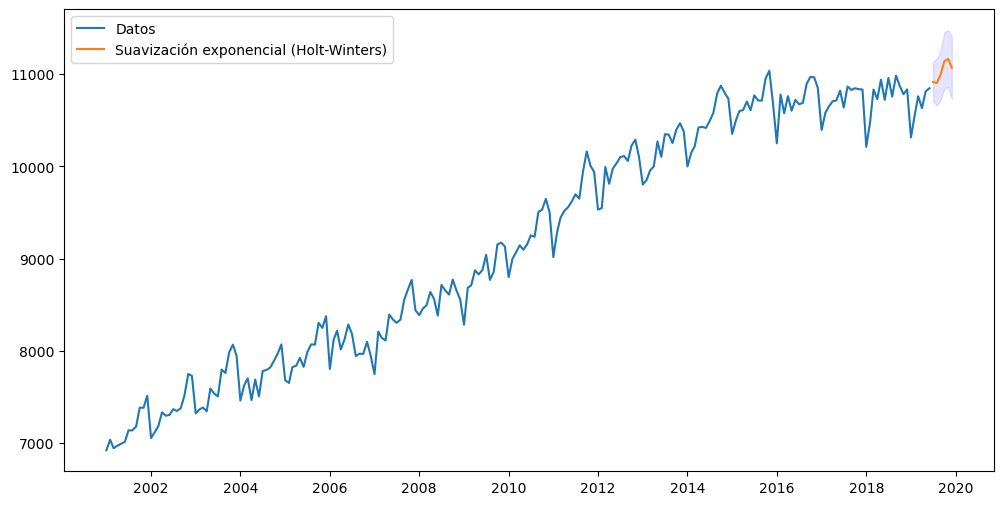

In [33]:
fig = plt.figure(figsize=(12, 6))
plt.plot(data["Ocupados"],label="Datos")
plt.plot(preds_hw_final['Pronóstico puntual'],label="Suavización exponencial (Holt-Winters)")
plt.fill_between(preds_hw_final.index ,preds_hw_final['lower_95'], preds_hw_final['upper_95'], color='blue', alpha=0.1)
plt.legend()
plt.show()